# Sobre o dataset
[Link para download do dataset](https://archive.ics.uci.edu/dataset/186/wine+quality)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Implementando a classe e os métodos fit e predict


In [29]:

# Implementando o metodo
class LinearRegression:
    def __init__ (self, n_features ,learning_rate = 0.01):
        self.coeficiente = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.cost_history = []

# a predição de uam regressão multipla é o calculo de uma regressão simples aplicada a todos os valores em um vetor
    def predict_single(self, x):
        return sum(w * xi for w, xi in zip(self.coeficiente, x)) + self.bias

    def predict(self,X):
        return [self.predict_single(x) for x in X]

    def compute_cost(self, X, y):
        predictions = self.predict(X)
        n = len(y)
        return sum((pred - actual)**2 for pred, actual in zip(predictions, y)) / n

    def r_squared(self, X, y):
        predictions = self.predict(X)
        y_mean = np.mean(y)

        ss_res = sum((actual - predict) ** 2 for actual, predict in zip(y, predictions))
        ss_tot = sum((actual - y_mean) ** 2 for actual in y)
        return 1 - (ss_res / ss_tot)

    def fit(self, X, Y, epocas):
        X = np.array(X)
        Y = np.array(Y)

        n = len(Y)
        n_features = len(X[0])

        for epoca in range(epocas):
            predictions = self.predict(X)
            errors = [pred - actual for pred, actual in zip(predictions, Y)]

            for j in range(n_features):
                grad = (2/n) * sum(errors[i] * X[i][j] for i in range(n))
                self.coeficiente[j] -= self.lr * grad

            grad_b = (2/n) * sum(errors)
            self.bias -= self.lr * grad_b

            cost = self.compute_cost(X, Y)
            self.cost_history.append(cost)

            if epoca % 50 == 0:
                print(f"  Epoch {epoca:4d} | Cost: {cost:.4f}")
        return self
    




## Importando o dataset

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


Text(0.5, 1.0, 'Quantidade de Instancias x qualidade do vinho (%)')

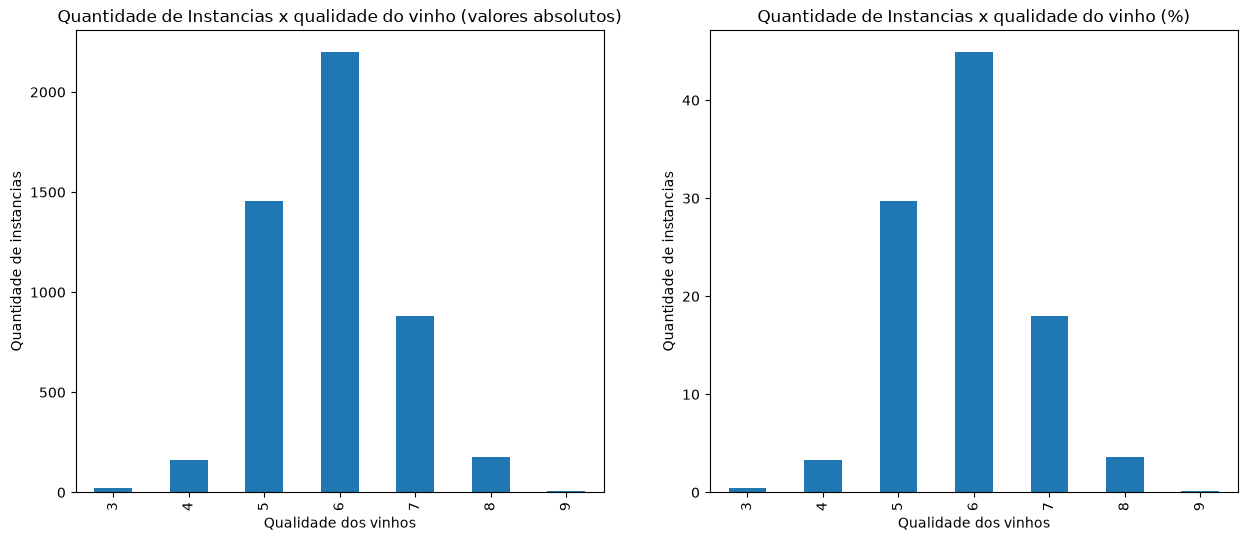

In [30]:
data = pd.read_csv('../datasets/wine+quality/winequality-white.csv',delimiter=';' )

print(data.info())
#print(data.head())
#print(data.sample)

## verificar se possuem correlacao entre os dados

#data.drop("free sulfur dioxide",axis=1, inplace=True)
#data.drop("citric acid",axis=1, inplace=True)
#data.drop("pH",axis=1, inplace=True)
#data.drop("sulphates",axis=1, inplace=True)
#data.drop("residual sugar",axis=1, inplace=True)

data = pd.DataFrame(data)
correlacao_target = data.corr(numeric_only= True)["quality"].sort_values(ascending=False)

correlacao = data.corr(numeric_only= True)
#print(correlacao_target, correlacao)

# mostrando quantidade de valores no dataset
fig, axes = plt.subplots(1,2, figsize=(15,6))

data["quality"].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Quantidade de Instancias x qualidade do vinho (valores absolutos)')
axes[0].set_ylabel('Quantidade de instancias')
axes[0].set_xlabel('Qualidade dos vinhos')
(data["quality"].value_counts(normalize= True).sort_index() * 100).plot(kind= "bar", ax= axes[1])
axes[1].set_ylabel('Quantidade de instancias')
axes[1].set_xlabel('Qualidade dos vinhos')
axes[1].set_title('Quantidade de Instancias x qualidade do vinho (%)')

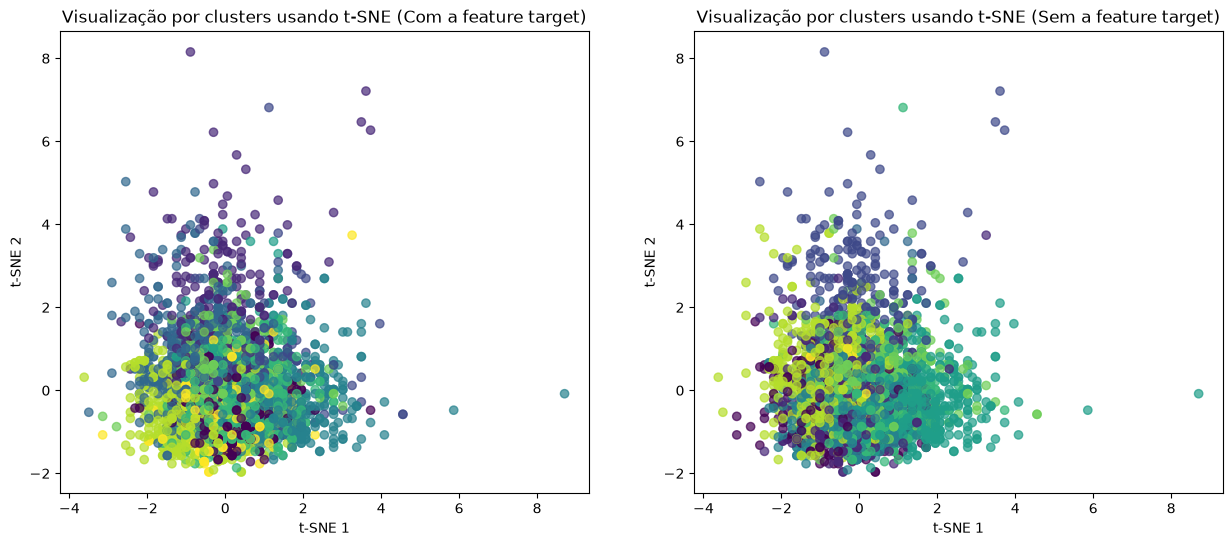

In [31]:
# plotando tsne
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

tsne = TSNE(n_components= 2 , perplexity= 30, random_state= 42)
scaler = StandardScaler()
dataset_types_com_target = data.select_dtypes(include="number")

dataset_types_sem_target = data
dataset_types_sem_target.drop('quality', axis=1, inplace= True)
dataset_types_sem_target = dataset_types_sem_target.select_dtypes(include='number')


kmeans = KMeans(
    n_clusters=10,
    random_state=42
)


dataset_types_com_target = scaler.fit_transform(dataset_types_com_target)
dataset_types_sem_target = scaler.fit_transform(dataset_types_sem_target)

clusters_com_target = kmeans.fit_predict(dataset_types_com_target)
clusters_sem_target = kmeans.fit_predict(dataset_types_sem_target)



tsne_data_com_target = pd.DataFrame({
    "TSNE1": dataset_types_com_target[:,0],
    "TSNE2": dataset_types_com_target[:,1],
    "cluster": clusters_com_target
})

tsne_data_sem_target = pd.DataFrame({
    "TSNE1": dataset_types_sem_target[:,0],
    "TSNE2": dataset_types_sem_target[:,1],
    "cluster": clusters_sem_target
})

fig, axes = plt.subplots(1,2, figsize=(15,6))

axes[0].scatter(tsne_data_com_target["TSNE1"],
    tsne_data_com_target["TSNE2"],
    c=tsne_data_com_target["cluster"],
    alpha=0.7)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].set_title("Visualização por clusters usando t-SNE (Com a feature target)")

axes[1].scatter(tsne_data_sem_target["TSNE1"],
    tsne_data_sem_target["TSNE2"],
    c=tsne_data_sem_target["cluster"],
    alpha=0.7)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("Visualização por clusters usando t-SNE (Sem a feature target)")



plt.show()


# Preparando os dados e definindo conjunto de treino e de teste


In [32]:
def separar_dados(X, Y, proporcao_treino, random_seed):
    rng = np.random.default_rng(random_seed)
    scaler = StandardScaler()

    n = len(X);

    n_treino = int(n * proporcao_treino)

    indices = np.arange(n)
    rng.shuffle(indices)

    # selecionando aleatoriamente quais indices serão usados para treino e quais seerã usados para teste
    indices_treino = indices[:n_treino]
    indices_teste = indices[n_treino:]


    X_treino = X.iloc[indices_treino]
    X_teste  = X.iloc[indices_teste]
    Y_treino = Y.iloc[indices_treino]
    Y_teste  = Y.iloc[indices_teste]

    X_treino = scaler.fit_transform(X_treino)
    X_teste = scaler.fit_transform(X_teste)

    return X_treino, X_teste, Y_treino, Y_teste


data = pd.read_csv('../datasets/wine+quality/winequality-white.csv',delimiter=';' )
data = pd.DataFrame(data)

y = data["quality"]
X = data


# removendo a coluna resposta (quality)
X.drop("quality", axis= 1, inplace= True)

X = pd.DataFrame(X)
feature_names = X.columns.to_numpy()

X_treino, X_teste, Y_treino, Y_teste = separar_dados(X, y, 0.8, 42)

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_treino, Y_treino, 200)

y_predito = model.predict(X_teste)

comparacao = pd.DataFrame({
    'valores preditos': y_predito,
    'valores reais': Y_teste
    
})

display(comparacao.round(4))

mse = mean_squared_error(Y_teste, y_predito)
r2 = r2_score(Y_teste, y_predito)

metrics = pd.DataFrame({
    'conjunto': ['teste'],
    'MSE': [mse],
    'R²': [r2],
})

display(metrics.round(4))

coefficients = pd.DataFrame({
    'feature': feature_names,
    'coeficiente_padronizado': model.coef_,
}).sort_values('coeficiente_padronizado')
display(coefficients.round(4))

print(f'MSE: {mse} e R2: {r2}' )


,valores preditos,valores reais
1832,5.9407,7
2227,5.4895,5
2929,5.6325,6
1457,6.5474,6
3001,6.0946,7
...,...,...
437,6.7974,8
491,6.5621,7
2189,5.7735,6
4802,6.4974,8


,conjunto,MSE,R²
0,teste,0.5519,0.2766


,feature,coeficiente_padronizado
7,density,-0.3865
1,volatile acidity,-0.1817
6,total sulfur dioxide,-0.0298
4,chlorides,-0.0058
2,citric acid,0.0148
0,fixed acidity,0.0403
9,sulphates,0.0751
5,free sulfur dioxide,0.0774
8,pH,0.0971
10,alcohol,0.2663


MSE: 0.5519367334434816 e R2: 0.2766325659985126


In [ ]:


#modelo = LinearRegression(n_features=11)

#modelo.fit(X_treino, Y_treino, 500)